# 03 Geodemographic Clustering Analysis

This notebook executes the K-Means clustering algorithm, evaluates the elbow point, and identifies optimal consumer segments.

In [1]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns


In [2]:
percentages_file = r'../data/percentages.csv'
total_file = r'../data/testingdata.csv'

# Load the CSV files into pandas DataFrames
percentages_df = pd.read_csv(percentages_file)
total_df = pd.read_csv(total_file)

#percentages_df['LSOA21CD'] = percentages_df['LSOA21CD'].str.split(':').str[0].str.strip()
# Merge the two DataFrames based on the common variable 'LSOACD21'
# Use an inner join to keep only the rows in 'percentages' that have matching rows in 'Total'
combined_df = pd.merge(percentages_df, total_df, on='LSOA21CD', how='left')

# Display the first few rows of the combined DataFrame to verify the merge
print(combined_df.head())
df = combined_df


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\UTSM\\Documents\\Data for Clustering\\percentages.csv'

In [ ]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler

transformed_data = {}

# Loop through the DataFrame and apply Box-Cox transformation where possible
for column in df.columns[1:]:  # Exclude the 'LSOA21CD' column
    if (df[column] > 0).all():
        # Apply Box-Cox transformation for positive values
        transformed_data[column], _ = stats.boxcox(df[column])
    else:
        # Leave the column unchanged if it contains non-positive values
        transformed_data[column] = df[column]

# Convert back to a DataFrame
transformed_df = pd.DataFrame(transformed_data)

# Standardize the transformed data using z-scores
scaler = StandardScaler()
standardized_data = scaler.fit_transform(transformed_df)

# Convert standardized data back into a DataFrame
standardized_df = pd.DataFrame(standardized_data, columns=transformed_df.columns)

# Add back the 'LSOA21CD' column to the standardized DataFrame
combined_df['LSOA21CD'] = df['LSOA21CD']

# Display the standardized DataFrame
print(standardized_df)


       %Conveniance  %Discounter  %Premium    %Value  %Online Often  \
0          0.367332     0.107779 -0.529418  0.192474       0.326558   
1         -0.535547    -0.214720  0.469638  0.408279      -1.178233   
2         -0.264240    -0.901614  0.677064  0.979001      -1.418174   
3          0.096862    -1.022394  1.441236  0.426467      -1.500694   
4          0.821100    -1.894407  0.481422  1.545729      -1.449111   
...             ...          ...       ...       ...            ...   
35667     -0.519844     0.755727 -1.721129  0.048793       0.387374   
35668      0.039751     0.554502 -1.039047  0.155189       0.392517   
35669     -1.453064     0.158963 -1.422740  0.505973       0.877226   
35670     -0.276946    -0.001265 -1.491869  0.473795       0.363460   
35671     -0.422814    -0.207631  0.772353  0.150471      -0.394148   

       %Online Sometimes  %Online Rarely  %Online Never  %Less than £50  \
0               0.910370       -0.444646      -0.794171       -0.813642 

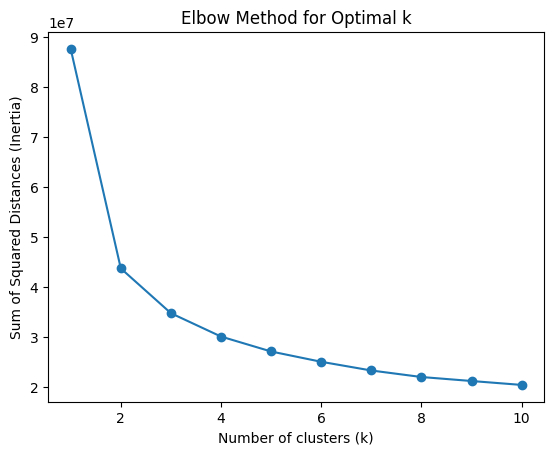

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select the standardized data (excluding the categorical column like LSOA21CD)
X = combined_df.drop(columns=['LSOA21CD'])

# List to hold the sum of squared distances for each k value
sse = []

# Try different numbers of clusters (for example, from 1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    # Append the sum of squared distances (inertia)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.show()


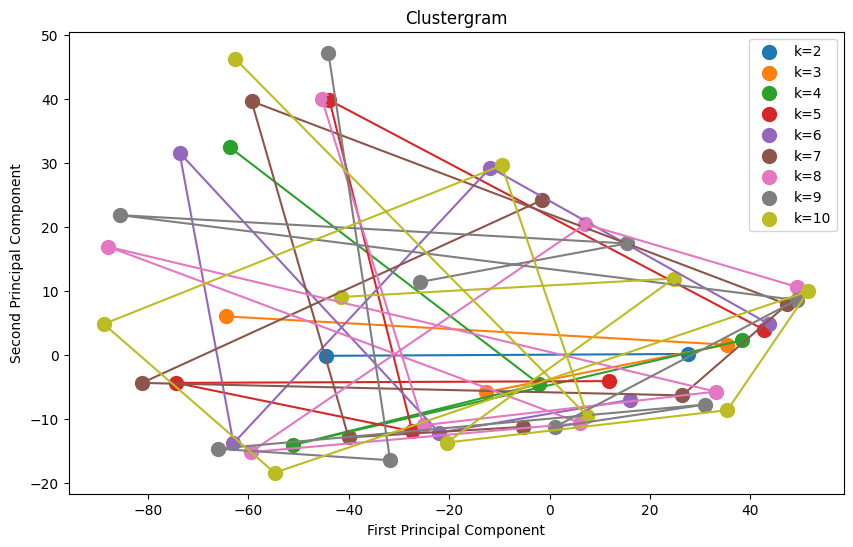

In [ ]:
# Function to create a clustergram
def plot_clustergram(X, max_k=10):
    pca = PCA(n_components=2)  # Reduce data to 2D using PCA for easier plotting
    reduced_data = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 6))
    
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(reduced_data)
        centroids = kmeans.cluster_centers_
        
        # Plot cluster centers for each k
        plt.scatter(centroids[:, 0], centroids[:, 1], label=f'k={k}', s=100)
        plt.plot(centroids[:, 0], centroids[:, 1], '-o')
    
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Clustergram')
    plt.legend()
    plt.show()

# Call the function to plot the clustergram
plot_clustergram(X, max_k=10)


In [3]:
# Set the optimal number of clusters based on the elbow method (e.g., 4 clusters)
optimal_k = 4

# Initialize and fit the KMeans model with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
combined_df['Cluster'] = kmeans.fit_predict(X)

# Display the first few rows with the cluster assignments
print(combined_df[['LSOA21CD', 'Cluster']].head())


NameError: name 'X' is not defined

In [45]:
# Skip the first row of the combined_df if it contains non-numeric data
# For further processing, ignore that row
numeric_columns = combined_df.iloc[1:].select_dtypes(include=['number']).columns

# Group by the 'Cluster' column and calculate the mean of each numeric variable in each cluster
cluster_summary = combined_df.iloc[1:].groupby('Cluster')[numeric_columns].mean()

# Display the summary of clusters
print(cluster_summary)


         %Conveniance  %Discounter  %Premium     %Value  %Online Often  \
Cluster                                                                  
0            6.625211     6.305632  2.170173  84.862185      13.807495   
1            6.499375     8.990230  1.060195  83.176371      23.664374   
2            6.604467     7.764885  1.449974  83.947002      21.678940   
3            6.711545     6.989530  1.782054  84.384127      18.011235   

         %Online Sometimes  %Online Rarely  %Online Never  %Less than £50  \
Cluster                                                                     
0                51.034670       26.838891       8.318944       22.120609   
1                52.218316       18.143886       5.971292       21.176155   
2                52.350509       19.251267       6.719284       21.924636   
3                52.204232       22.664318       7.120216       21.590721   

          %£50-100  ...  %Routine/Unskilled Jobs  \
Cluster             ...                 

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming you have a DataFrame `df` with your features and a 'Cluster' column representing the clusters
# Exclude the 'Cluster' and 'LSOA21CD' columns to calculate z-scores
features = df.drop(columns=['Cluster', 'LSOA21CD'])

# Calculate Z-scores
scaler = StandardScaler()
z_scores = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Add the Cluster labels back to the z-score DataFrame
z_scores['Cluster'] = df['Cluster']

# Calculate the mean z-scores for each cluster
cluster_means = z_scores.groupby('Cluster').mean()

# Transpose the DataFrame so that we can easily plot it
cluster_means_t = cluster_means.T


<Figure size 1000x600 with 0 Axes>

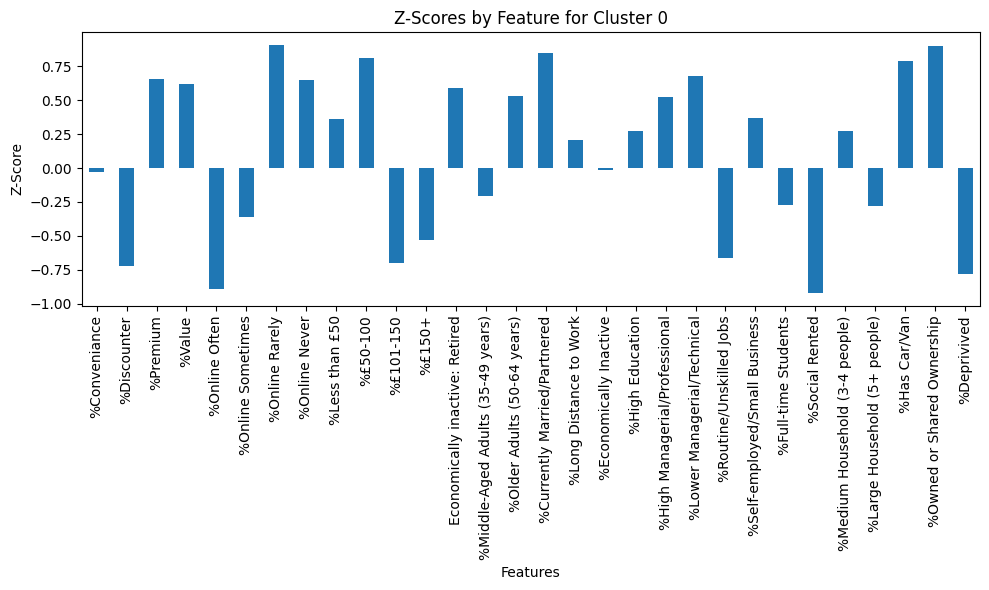

<Figure size 1000x600 with 0 Axes>

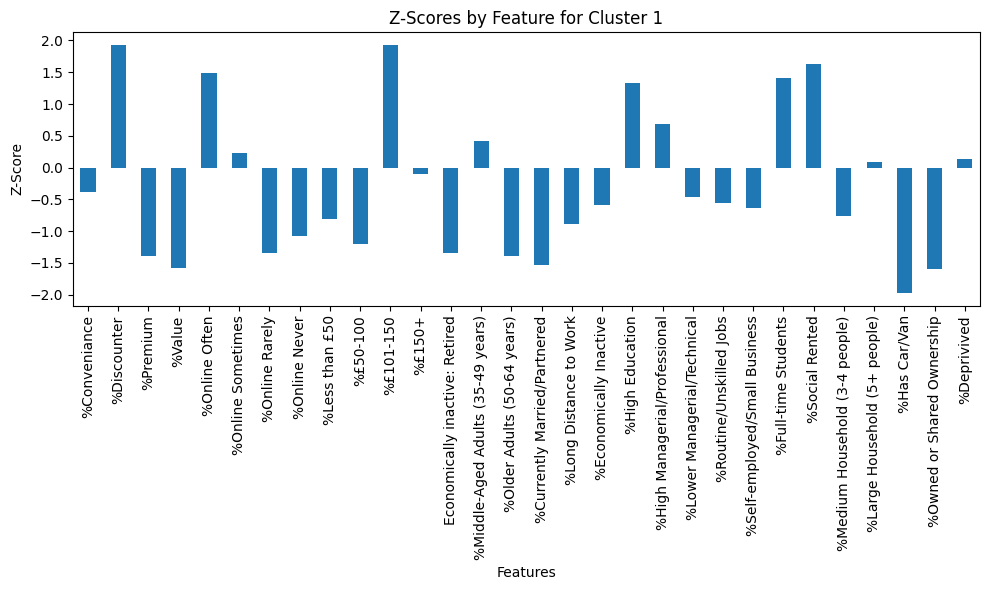

<Figure size 1000x600 with 0 Axes>

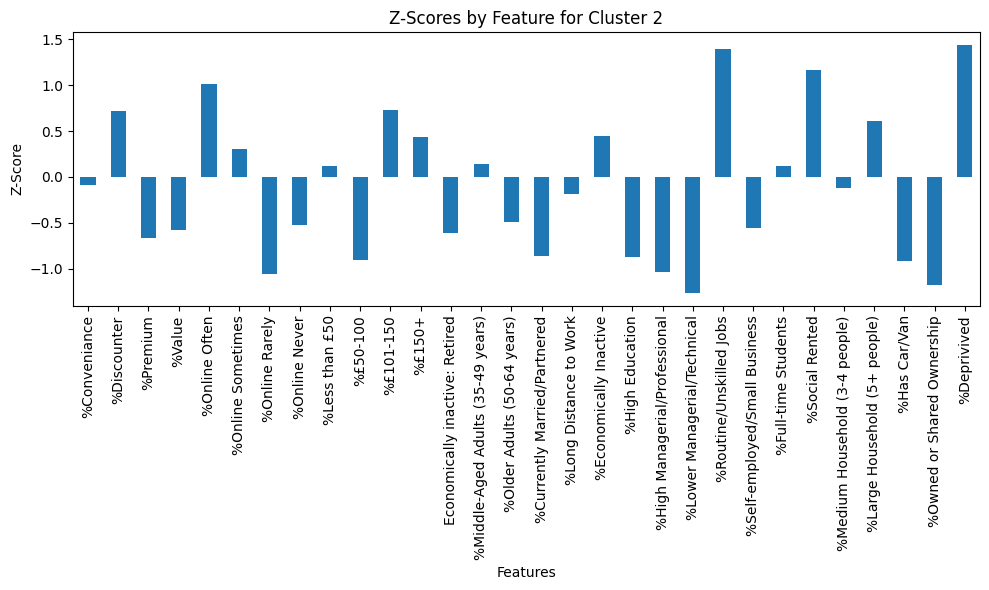

<Figure size 1000x600 with 0 Axes>

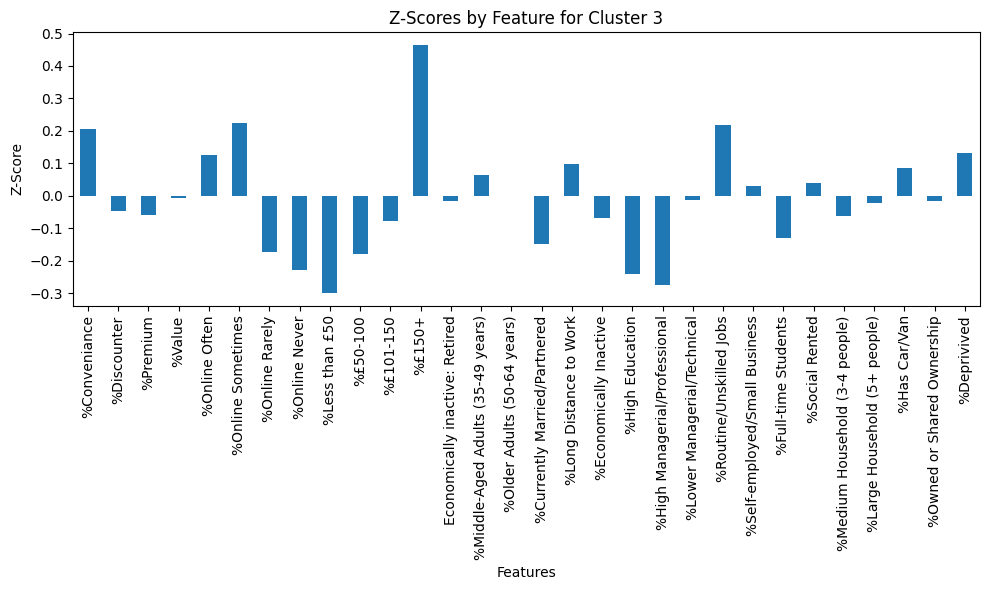

In [47]:
for cluster in cluster_means_t.columns:
    plt.figure(figsize=(10, 6))
    
    # Plot the Z-scores for the current cluster
    cluster_means_t[[cluster]].plot(kind='bar', figsize=(10, 6), legend=False)
    
    # Set plot title and labels
    plt.title(f'Z-Scores by Feature for Cluster {cluster}')
    plt.xlabel('Features')
    plt.ylabel('Z-Score')
    
    # Rotate x-tick labels for better readability
    plt.xticks(rotation=90)
    
    # Display the plot
    plt.tight_layout()
    plt.show()


<Figure size 1000x600 with 0 Axes>

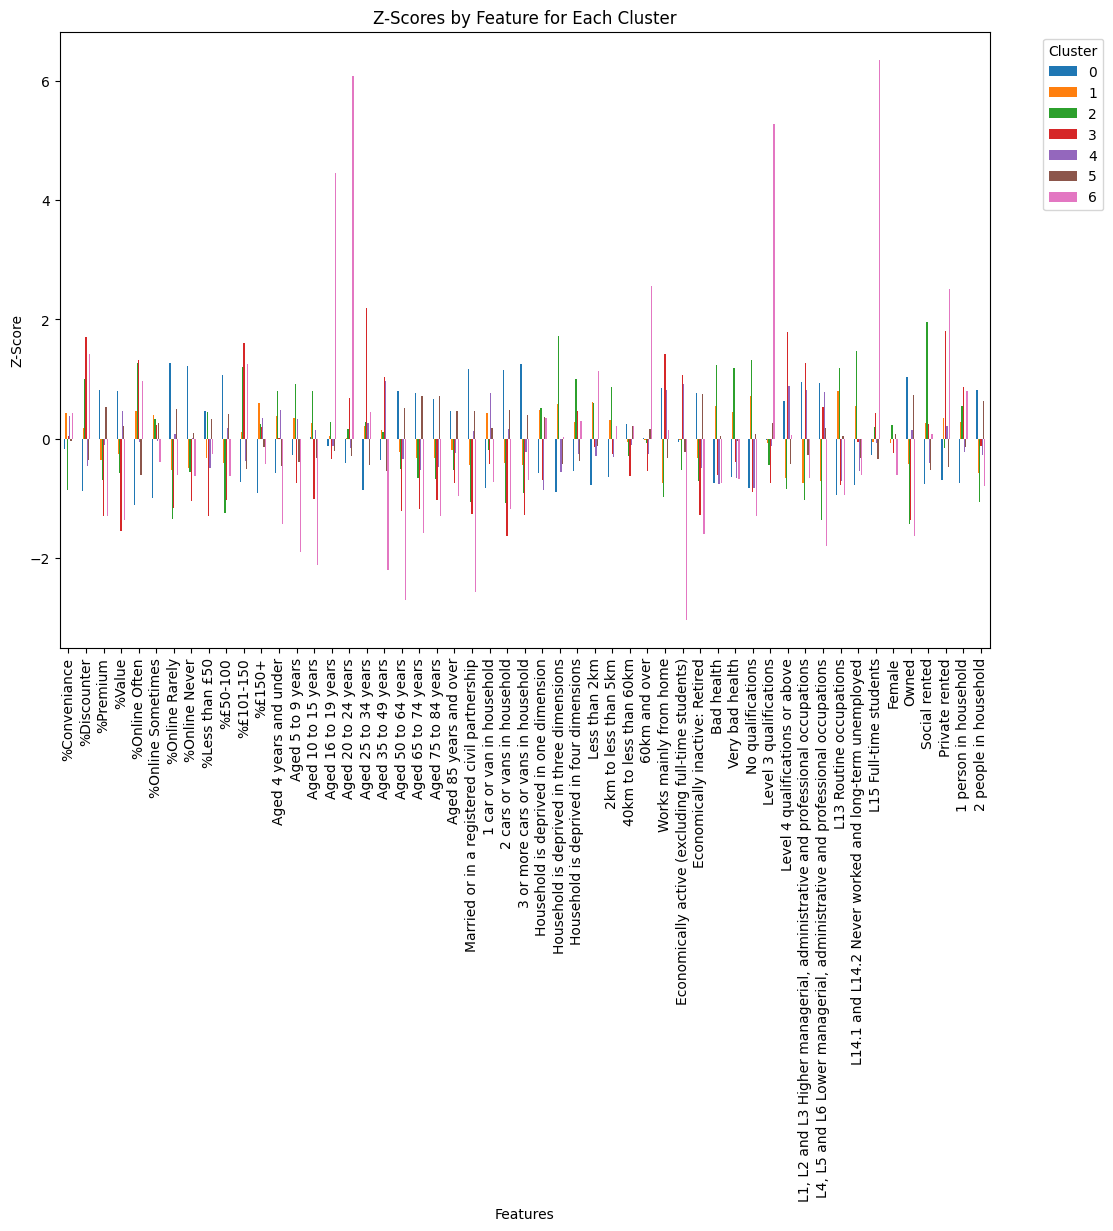

In [12]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot the z-scores for each cluster
cluster_means_t.plot(kind='bar', figsize=(12, 8))

plt.title('Z-Scores by Feature for Each Cluster')
plt.xlabel('Features')
plt.ylabel('Z-Score')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

plt.show()


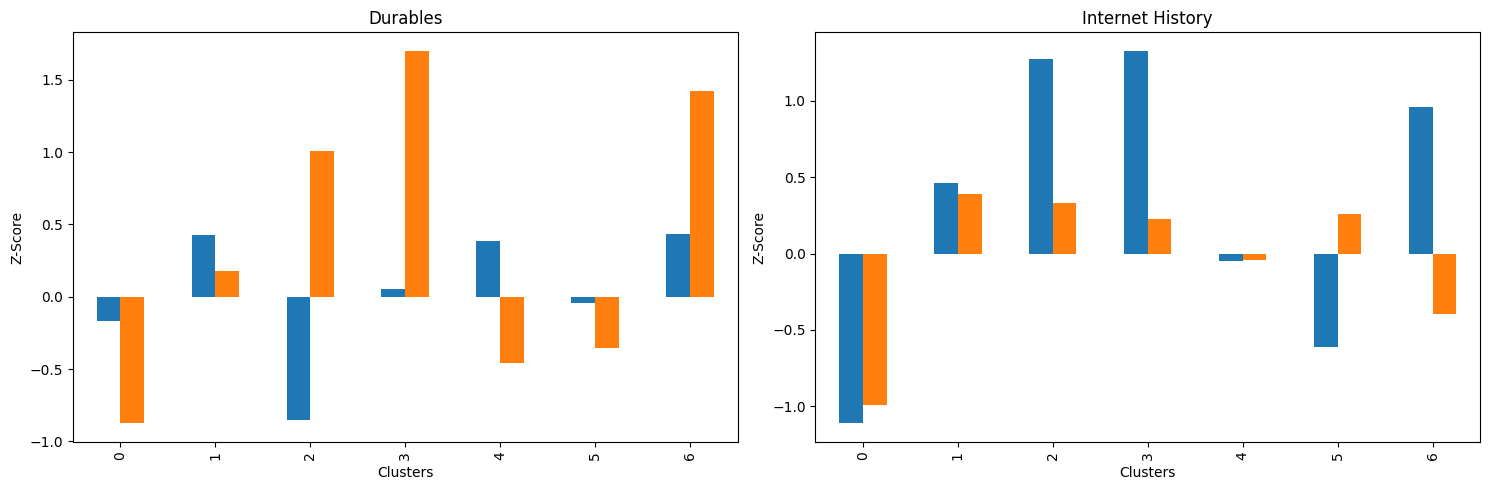

In [13]:
# Example: Grouped by different feature categories
feature_categories = {
    'Durables': ['%Conveniance', '%Discounter'],
    'Internet History': ['%Online Often', '%Online Sometimes'],
    # Add more categories and features accordingly
}

fig, axs = plt.subplots(nrows=1, ncols=len(feature_categories), figsize=(15, 5))

for ax, (category, feature_list) in zip(axs, feature_categories.items()):
    cluster_means[feature_list].plot(kind='bar', ax=ax, legend=False)
    ax.set_title(category)
    ax.set_xlabel('Clusters')
    ax.set_ylabel('Z-Score')

plt.tight_layout()
plt.show()


In [48]:
cluster_summary
output_file_path = '../data/combined_with_clusters4clusters.csv'
cluster_summary.to_csv(output_file_path, index=False)
